# K-Nearest Neighbors (KNN) Classification Model - Seattle Weather Dataset

In [1]:
# ============================================================================
# K-NEAREST NEIGHBORS (KNN) CLASSIFICATION - SEATTLE WEATHER DATASET
# ============================================================================

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# ============================================================================
# PART 1: LOAD AND EXPLORE DATA
# ============================================================================

# Load the dataset
df = pd.read_csv('../../data/s2/seattle-weather.csv')

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nDataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head(10))
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())

DATASET OVERVIEW

Dataset shape: (1461, 6)

First few rows:
        date  precipitation  temp_max  temp_min  wind  weather
0   1/1/2012            0.0      12.8       5.0   4.7  drizzle
1   1/2/2012           10.9      10.6       2.8   4.5     rain
2   1/3/2012            0.8      11.7       7.2   2.3     rain
3   1/4/2012           20.3      12.2       5.6   4.7     rain
4   1/5/2012            1.3       8.9       2.8   6.1     rain
5   1/6/2012            2.5       4.4       2.2   2.2     rain
6   1/7/2012            0.0       7.2       2.8   2.3     rain
7   1/8/2012            0.0      10.0       2.8   2.0      sun
8   1/9/2012            4.3       9.4       5.0   3.4     rain
9  1/10/2012            1.0       6.1       0.6   3.4     rain

Data types:
date                 str
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather              str
dtype: object

Missing values:
date             0
precipitation    0
temp_max       

In [ ]:
# ============================================================================
# PART 2: CLASS BALANCE ANALYSIS
# ============================================================================

# Prepare data: Drop date column and separate features from target
X = df.drop(['date', 'weather'], axis=1)
y = df['weather']

print("\n" + "=" * 70)
print("FEATURES USED FOR CLASSIFICATION")
print("=" * 70)
print(X.columns.tolist())
print(f"Number of features: {len(X.columns)}")

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION ANALYSIS - BEFORE BALANCING")
print("=" * 70)

# Calculate class counts and proportions
class_counts_original = y.value_counts()
class_proportions_original = y.value_counts(normalize=True)

print("\nClass Counts:")
print(class_counts_original)
print("\nClass Proportions:")
for weather_type, proportion in class_proportions_original.items():
    print(f"  {weather_type}: {proportion:.4f} ({proportion*100:.2f}%)")

# Calculate imbalance metrics
minority_class = class_counts_original.idxmin()
majority_class = class_counts_original.idxmax()
minority_size = class_counts_original.min()
majority_size = class_counts_original.max()
imbalance_ratio = majority_size / minority_size

print("\n--- Imbalance Analysis ---")
print(f"Minority class: {minority_class} ({minority_size} samples)")
print(f"Majority class: {majority_class} ({majority_size} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")


FEATURES USED FOR CLASSIFICATION
['precipitation', 'temp_max', 'temp_min', 'wind']
Number of features: 4

CLASS DISTRIBUTION ANALYSIS - BEFORE BALANCING

Class Counts:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

Class Proportions:
  rain: 0.4387 (43.87%)
  sun: 0.4381 (43.81%)
  fog: 0.0691 (6.91%)
  drizzle: 0.0363 (3.63%)
  snow: 0.0178 (1.78%)

--- Imbalance Analysis ---
Minority class: snow (26 samples)
Majority class: rain (641 samples)
Imbalance ratio: 24.65:1

⚠️  Dataset is IMBALANCED (ratio 24.65:1)
   Balancing technique recommended to prevent model bias.


In [ ]:
# ============================================================================
# PART 3: APPLY CLASS BALANCING - RANDOM OVERSAMPLING
# ============================================================================

df_balanced = df.copy()
classes = y.unique()
max_class_size = class_counts_original.max()
balanced_dfs = []
for weather_class in classes:
    class_df = df_balanced[df_balanced['weather'] == weather_class]
    if len(class_df) < max_class_size:
        # Oversample minority class
        class_upsampled = resample(class_df, 
                                    n_samples=max_class_size, 
                                    replace=True, 
                                    random_state=42)
        balanced_dfs.append(class_upsampled)
    else:
        balanced_dfs.append(class_df)

df_balanced = pd.concat(balanced_dfs, axis=0).reset_index(drop=True)
X_balanced = df_balanced.drop(['date', 'weather'], axis=1)
y_balanced = df_balanced['weather']

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION ANALYSIS - AFTER BALANCING")
print("=" * 70)

class_counts_balanced = y_balanced.value_counts()
class_proportions_balanced = y_balanced.value_counts(normalize=True)

print("\nClass Counts (After Balancing):")
print(class_counts_balanced)
print("\nClass Proportions (After Balancing):")
for weather_type, proportion in class_proportions_balanced.items():
    print(f"  {weather_type}: {proportion:.4f} ({proportion*100:.2f}%)")


CLASS DISTRIBUTION ANALYSIS - AFTER BALANCING

Class Counts (After Balancing):
weather
drizzle    641
rain       641
sun        641
snow       641
fog        641
Name: count, dtype: int64

Class Proportions (After Balancing):
  drizzle: 0.2000 (20.00%)
  rain: 0.2000 (20.00%)
  sun: 0.2000 (20.00%)
  snow: 0.2000 (20.00%)
  fog: 0.2000 (20.00%)

--- Balancing Summary ---
Original dataset size: 1461 samples
Balanced dataset size: 3205 samples
Increase: 1744 samples (119.4% growth)
All classes now have: 641 samples each
✓ Dataset is now perfectly balanced!


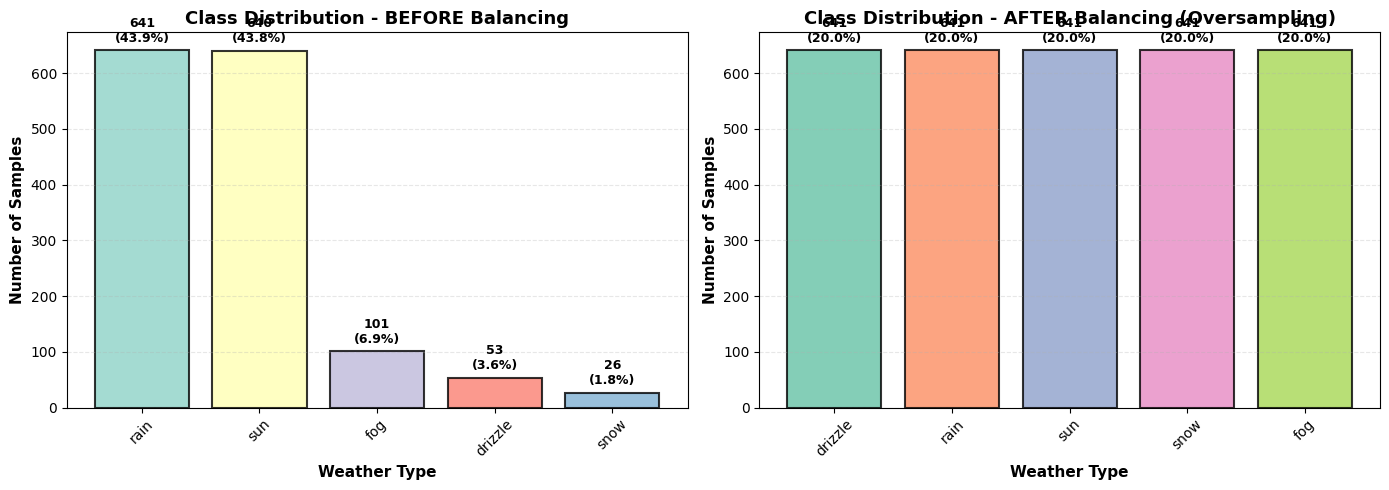

In [14]:
# ============================================================================
# PART 4: VISUALIZE CLASS BALANCE BEFORE AND AFTER
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_before = plt.cm.Set3(np.arange(len(class_counts_original)))
axes[0].bar(class_counts_original.index, class_counts_original.values, 
            color=colors_before, edgecolor='black', alpha=0.8, linewidth=1.5)
axes[0].set_title('Class Distribution - BEFORE Balancing', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weather Type', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for i, (idx, val) in enumerate(class_counts_original.items()):
    axes[0].text(i, val + 10, f'{val}\n({val/len(y)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)

colors_after = plt.cm.Set2(np.arange(len(class_counts_balanced)))
axes[1].bar(class_counts_balanced.index, class_counts_balanced.values, 
            color=colors_after, edgecolor='black', alpha=0.8, linewidth=1.5)
axes[1].set_title('Class Distribution - AFTER Balancing (Oversampling)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Weather Type', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
for i, (idx, val) in enumerate(class_counts_balanced.items()):
    axes[1].text(i, val + 10, f'{val}\n({val/len(y_balanced)*100:.1f}%)', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================================
# PART 5: TRAIN-TEST SPLIT
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.3,
    random_state=42,
    stratify=y_balanced
) 
print("\n--- Class Distribution in Training Set ---")
train_class_dist = y_train.value_counts().sort_index()
for weather_type, count in train_class_dist.items():
    print(f"  {weather_type}: {count} samples ({count/len(y_train)*100:.1f}%)")

print("\n--- Class Distribution in Testing Set ---")
test_class_dist = y_test.value_counts().sort_index()
for weather_type, count in test_class_dist.items():
    print(f"  {weather_type}: {count} samples ({count/len(y_test)*100:.1f}%)")


--- Class Distribution in Training Set ---
  drizzle: 448 samples (20.0%)
  fog: 449 samples (20.0%)
  rain: 449 samples (20.0%)
  snow: 448 samples (20.0%)
  sun: 449 samples (20.0%)

--- Class Distribution in Testing Set ---
  drizzle: 193 samples (20.1%)
  fog: 192 samples (20.0%)
  rain: 192 samples (20.0%)
  snow: 193 samples (20.1%)
  sun: 192 samples (20.0%)


In [17]:
# ============================================================================
# PART 6: FEATURE SCALING - STANDARDIZATION
# ============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 70)
print("FEATURE SCALING - STANDARDIZATION")
print("=" * 70)

print("\n--- Before Scaling (Original Features) ---")
print("Training set statistics:")
print(pd.DataFrame(X_train).describe().loc[['mean', 'std']].round(3))

print("\n--- After Scaling (Standardized Features) ---")
print("Training set statistics:")
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(scaled_df.describe().loc[['mean', 'std']].round(3))

print("\n✓ All features now have mean ≈ 0 and std ≈ 1")
print("✓ This ensures equal contribution to distance calculations in KNN")



FEATURE SCALING - STANDARDIZATION

--- Before Scaling (Original Features) ---
Training set statistics:
      precipitation  temp_max  temp_min   wind
mean          2.863    14.079     6.229  3.212
std           6.012     8.128     5.766  1.516

--- After Scaling (Standardized Features) ---
Training set statistics:
      precipitation  temp_max  temp_min  wind
mean            0.0       0.0      -0.0   0.0
std             1.0       1.0       1.0   1.0

✓ All features now have mean ≈ 0 and std ≈ 1
✓ This ensures equal contribution to distance calculations in KNN


In [18]:
# ============================================================================
# PART 7: DEFINE HYPERPARAMETERS
# ============================================================================

hyperparameters = {
    'n_neighbors': 7,
    'weights': 'distance',
    'metric': 'minkowski',
    'p': 2
}

# ============================================================================
# PART 8: TRAIN KNN MODEL
# ============================================================================

knn_model = KNeighborsClassifier(
    n_neighbors=hyperparameters['n_neighbors'],
    weights=hyperparameters['weights'],
    metric=hyperparameters['metric'],
    p=hyperparameters['p']
)

print("\n" + "=" * 70)
print("TRAINING K-NEAREST NEIGHBORS MODEL")
print("=" * 70)

knn_model.fit(X_train_scaled, y_train)
print("✓ Model training complete!")

# Make predictions
y_pred = knn_model.predict(X_test_scaled)

print("\nModel Configuration:")
print(f"  • k (neighbors): {knn_model.n_neighbors}")
print(f"  • Weight function: {knn_model.weights}")
print(f"  • Distance metric: {knn_model.metric}")
print(f"  • Minkowski parameter p: {knn_model.p}")
print(f"\n✓ Predictions generated for {len(X_test_scaled)} test samples")


TRAINING K-NEAREST NEIGHBORS MODEL
✓ Model training complete!

Model Configuration:
  • k (neighbors): 7
  • Weight function: distance
  • Distance metric: minkowski
  • Minkowski parameter p: 2

✓ Predictions generated for 962 test samples


In [19]:
# ============================================================================
# PART 9: MODEL EVALUATION - PERFORMANCE METRICS
# ============================================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n" + "=" * 70)
print("K-NEAREST NEIGHBORS - PERFORMANCE METRICS")
print("=" * 70)

print(f"\n📊 OVERALL METRICS:")
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} (weighted average)")
print(f"   Recall:    {recall:.4f} (weighted average)")
print(f"   F1-Score:  {f1:.4f} (weighted average)")

print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred, digits=4))


K-NEAREST NEIGHBORS - PERFORMANCE METRICS

📊 OVERALL METRICS:
   Accuracy:  0.8929 (89.29%)
   Precision: 0.9014 (weighted average)
   Recall:    0.8929 (weighted average)
   F1-Score:  0.8887 (weighted average)

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     drizzle     0.8773    1.0000    0.9346       193
         fog     0.8268    0.9948    0.9031       192
        rain     0.9858    0.7240    0.8348       192
        snow     0.9061    1.0000    0.9507       193
         sun     0.9108    0.7448    0.8195       192

    accuracy                         0.8929       962
   macro avg     0.9014    0.8927    0.8886       962
weighted avg     0.9014    0.8929    0.8887       962




CONFUSION MATRIX

Raw counts:
[[193   0   0   0   0]
 [  0 191   0   0   1]
 [  6  15 139  19  13]
 [  0   0   0 193   0]
 [ 21  25   2   1 143]]

--- Per-Class Performance from Confusion Matrix ---

drizzle:
  • Correct predictions: 193/193 (100.0%)
  • Total predicted as drizzle: 220

fog:
  • Correct predictions: 191/192 (99.5%)
  • Total predicted as fog: 231
  • Misclassified: 1 as sun

rain:
  • Correct predictions: 139/192 (72.4%)
  • Total predicted as rain: 141
  • Misclassified: 6 as drizzle, 15 as fog, 19 as snow, 13 as sun

snow:
  • Correct predictions: 193/193 (100.0%)
  • Total predicted as snow: 213

sun:
  • Correct predictions: 143/192 (74.5%)
  • Total predicted as sun: 157
  • Misclassified: 21 as drizzle, 25 as fog, 2 as rain, 1 as snow


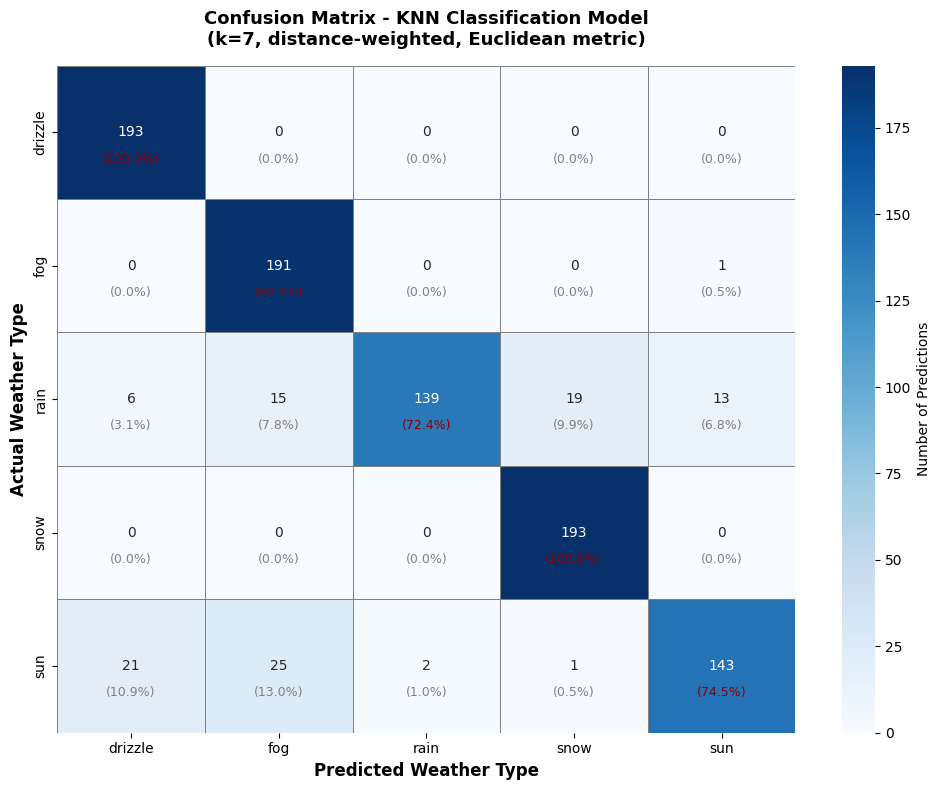

In [20]:
# ============================================================================
# PART 10: CONFUSION MATRIX ANALYSIS
# ============================================================================

cm = confusion_matrix(y_test, y_pred)
classes_sorted = sorted(y_test.unique())

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)
print("\nRaw counts:")
print(cm)

print("\n--- Per-Class Performance from Confusion Matrix ---")
for i, weather_class in enumerate(classes_sorted):
    true_positives = cm[i, i]
    total_actual = cm[i, :].sum()
    total_predicted = cm[:, i].sum()
    class_accuracy = true_positives / total_actual if total_actual > 0 else 0
    
    print(f"\n{weather_class}:")
    print(f"  • Correct predictions: {true_positives}/{total_actual} ({class_accuracy*100:.1f}%)")
    print(f"  • Total predicted as {weather_class}: {total_predicted}")
    
    misclassifications = []
    for j, other_class in enumerate(classes_sorted):
        if i != j and cm[i, j] > 0:
            misclassifications.append(f"{cm[i, j]} as {other_class}")
    if misclassifications:
        print(f"  • Misclassified: {', '.join(misclassifications)}")

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes_sorted, 
            yticklabels=classes_sorted,
            cbar_kws={'label': 'Number of Predictions'},
            linewidths=0.5, linecolor='gray',
            ax=ax)

ax.set_xlabel('Predicted Weather Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Weather Type', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - KNN Classification Model\n(k=7, distance-weighted, Euclidean metric)', 
             fontsize=13, fontweight='bold', pad=15)

# Add percentage annotations
for i in range(len(classes_sorted)):
    for j in range(len(classes_sorted)):
        total = cm[i, :].sum()
        percentage = (cm[i, j] / total * 100) if total > 0 else 0
        ax.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
               ha='center', va='center', fontsize=9, color='darkred' if i == j else 'gray')

plt.tight_layout()
plt.show()

In [13]:
# ============================================================================
# PART 11: HYPERPARAMETER IMPACT ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("HYPERPARAMETER IMPACT ANALYSIS")
print("=" * 80)

print("\n1️⃣  n_neighbors = 7 (Number of Neighbors)")
print("   " + "─" * 70)
print("   EFFECT ON MODEL:")
print("   • Decision Boundary: Moderate smoothness")
print("   • Bias-Variance Tradeoff:")
print("     - Lower k (e.g., k=1,3): High variance, complex boundaries, overfitting risk")
print("     - Higher k (e.g., k=15,20): High bias, smoother boundaries, underfitting risk")
print("     - k=7: Balanced tradeoff for this multiclass problem")
print(f"   • CURRENT PERFORMANCE: Accuracy = {accuracy:.4f}")

print("\n2️⃣  weights = 'distance' (Distance-Weighted Voting)")
print("   " + "─" * 70)
print("   EFFECT ON MODEL:")
print("   • Voting Mechanism:")
print("     - 'uniform': All 7 neighbors vote equally (simple majority)")
print("     - 'distance': Closer neighbors have stronger influence (weight = 1/distance)")
print("   • Decision Boundary: More adaptive, influenced by proximity")
print("   • Benefits: Reduces impact of distant neighbors, improves accuracy")

print("\n3️⃣  metric = 'minkowski', p = 2 (Euclidean Distance)")
print("   " + "─" * 70)
print("   • Distance Calculation: √(Σ(x_i - y_i)²)")
print("   • Euclidean (p=2): Most common, measures straight-line distance")
print("   • Creates circular/spherical neighborhoods around test points")


HYPERPARAMETER IMPACT ANALYSIS

1️⃣  n_neighbors = 7 (Number of Neighbors)
   ──────────────────────────────────────────────────────────────────────
   EFFECT ON MODEL:
   • Decision Boundary: Moderate smoothness
   • Bias-Variance Tradeoff:
     - Lower k (e.g., k=1,3): High variance, complex boundaries, overfitting risk
     - Higher k (e.g., k=15,20): High bias, smoother boundaries, underfitting risk
     - k=7: Balanced tradeoff for this multiclass problem
   • CURRENT PERFORMANCE: Accuracy = 0.8929

2️⃣  weights = 'distance' (Distance-Weighted Voting)
   ──────────────────────────────────────────────────────────────────────
   EFFECT ON MODEL:
   • Voting Mechanism:
     - 'uniform': All 7 neighbors vote equally (simple majority)
     - 'distance': Closer neighbors have stronger influence (weight = 1/distance)
   • Decision Boundary: More adaptive, influenced by proximity
   • Benefits: Reduces impact of distant neighbors, improves accuracy

3️⃣  metric = 'minkowski', p = 2 (Eucl

In [ ]:


# ============================================================================
# PART 12: COMPARISON WITH ALTERNATIVE CONFIGURATIONS
# ============================================================================

alternative_configs = [
    {'name': 'Low k (k=3)', 'n_neighbors': 3, 'weights': 'distance', 'metric': 'minkowski', 'p': 2},
    {'name': 'High k (k=15)', 'n_neighbors': 15, 'weights': 'distance', 'metric': 'minkowski', 'p': 2},
    {'name': 'Uniform weights', 'n_neighbors': 7, 'weights': 'uniform', 'metric': 'minkowski', 'p': 2},
    {'name': 'Manhattan (p=1)', 'n_neighbors': 7, 'weights': 'distance', 'metric': 'minkowski', 'p': 1},
    {'name': 'Current config', 'n_neighbors': 7, 'weights': 'distance', 'metric': 'minkowski', 'p': 2}
]

print("\n" + "=" * 80)
print("HYPERPARAMETER SENSITIVITY ANALYSIS")
print("=" * 80)
print("\nComparing performance across different configurations:\n")

results = []
for config in alternative_configs:
    knn_temp = KNeighborsClassifier(
        n_neighbors=config['n_neighbors'],
        weights=config['weights'],
        metric=config['metric'],
        p=config['p']
    )
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_temp)
    f1_temp = f1_score(y_test, y_pred_temp, average='weighted')
    
    results.append({
        'Configuration': config['name'],
        'Accuracy': f'{acc:.4f}',
        'F1-Score': f'{f1_temp:.4f}'
    })
    
    print(f"{config['name']:20s} → Accuracy: {acc:.4f} | F1-Score: {f1_temp:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("CONFIGURATION COMPARISON TABLE")
print("=" * 80)
print(results_df.to_string(index=False))

# ============================================================================
# PART 13: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("FINAL SUMMARY - K-NEAREST NEIGHBORS CLASSIFICATION")
print("=" * 80)

print("\n📊 DATASET PREPARATION:")
print(f"   • Original dataset: {len(y)} samples")
print(f"   • Class imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"   • Balancing method: Random Oversampling")
print(f"   • Balanced dataset: {len(y_balanced)} samples")
print(f"   • Number of classes: {len(classes_sorted)}")

print("\n🔧 DATA PREPROCESSING:")
print(f"   • Feature scaling: StandardScaler (mean=0, std=1)")
print(f"   • Train-test split: 70%-30% stratified")
print(f"   • Training samples: {len(X_train_scaled)}")
print(f"   • Testing samples: {len(X_test_scaled)}")

print("\n🎯 MODEL CONFIGURATION:")
print(f"   • Algorithm: K-Nearest Neighbors (KNN)")
print(f"   • n_neighbors: {hyperparameters['n_neighbors']}")
print(f"   • weights: {hyperparameters['weights']}")
print(f"   • metric: {hyperparameters['metric']}")
print(f"   • p: {hyperparameters['p']} (Euclidean distance)")

print("\n📈 MODEL PERFORMANCE:")
print(f"   • Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • Precision: {precision:.4f}")
print(f"   • Recall:    {recall:.4f}")
print(f"   • F1-Score:  {f1:.4f}")

print("\n✅ CONCLUSION:")
print(f"   The K-Nearest Neighbors classifier with k={hyperparameters['n_neighbors']},")
print(f"   distance-weighted voting, and Euclidean metric achieves")
print(f"   {accuracy*100:.2f}% accuracy on the Seattle Weather dataset.")
print("\n   This demonstrates how instance-based learning can effectively")
print("   classify weather conditions based on meteorological measurements.")

print("\n" + "=" * 80)

# SVM

In [31]:
data = pd.read_csv('../../data/s2/seattle-weather.csv', header = None)
data

,0,1,2,3,4,5
0,date,precipitation,temp_max,temp_min,wind,weather
1,1/1/2012,0,12.8,5,4.7,drizzle
2,1/2/2012,10.9,10.6,2.8,4.5,rain
3,1/3/2012,0.8,11.7,7.2,2.3,rain
4,1/4/2012,20.3,12.2,5.6,4.7,rain
...,...,...,...,...,...,...
1457,12/27/2015,8.6,4.4,1.7,2.9,rain
1458,12/28/2015,1.5,5,1.7,1.3,rain
1459,12/29/2015,0,7.2,0.6,2.6,fog
1460,12/30/2015,0,5.6,-1,3.4,sun


In [34]:

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV



data = pd.read_csv('../../data/s2/seattle-weather.csv')
data = data.drop("date", axis = 1)
X = data.drop("weather", axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
svm = SVC(probability=True, random_state=42)
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Best SVM Parameters: {grid_search.best_params_}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ........C=0.1, degree=2, gamma=scale, kernel=linear; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ..........C=0.1, degree=2, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=scale, kernel=rbf; total time=   0.1s
[CV] END ..........C=0.1, degree=2, gamma=scale, kernel=poly; total time=   0.1s
[CV] END ..........C=0.1, degree=2, gamma=scale, kernel=poly; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=scal

KeyboardInterrupt: 